# Week 7: Визуализация данных
## Вариант 04 – Лондон (погода)

**Данные:** суточная витрина `daily_weather.csv` за 2024-01-01 … 2024-01-14

**Вопросы к данным:**
1. Как менялась температура по дням? Есть ли резкие скачки?
2. Как распределены значения температуры? Есть ли выбросы?
3. Какие дни были самыми дождливыми?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Matplotlib is building the font cache; this may take a moment.


In [3]:
mart_path = "../data/mart/variant_04/daily_weather.csv"
df = pd.read_csv(mart_path)

print(f"Загружено строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
df.head()

Загружено строк: 14
Колонки: ['date', 'avg_temp', 'min_temp', 'max_temp', 'avg_humidity', 'total_precip', 'avg_windspeed', 'city_id']


,date,avg_temp,min_temp,max_temp,avg_humidity,total_precip,avg_windspeed,city_id
0,2024-01-01,7.75,5.8,10.1,78.71,8.3,22.85,GB_LON
1,2024-01-02,11.04,8.8,12.9,86.96,9.6,29.64,GB_LON
2,2024-01-03,8.39,6.4,10.4,85.21,2.3,21.16,GB_LON
3,2024-01-04,6.82,4.9,8.2,89.54,27.7,14.84,GB_LON
4,2024-01-05,5.70,4.4,7.1,88.25,4.6,19.56,GB_LON


In [4]:
print(f"Тип date до преобразования: {df['date'].dtype}")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

print(f"Тип date после преобразования: {df['date'].dtype}")
print(f"Диапазон дат: {df['date'].min()} → {df['date'].max()}")

Тип date до преобразования: object
Тип date после преобразования: datetime64[ns]
Диапазон дат: 2024-01-01 00:00:00 → 2024-01-14 00:00:00


---
## График №1: Временной ряд (динамика температуры)

**Вопрос:** Как менялась средняя, минимальная и максимальная температура в Лондоне с 1 по 14 января 2024 года? Есть ли резкие скачки?

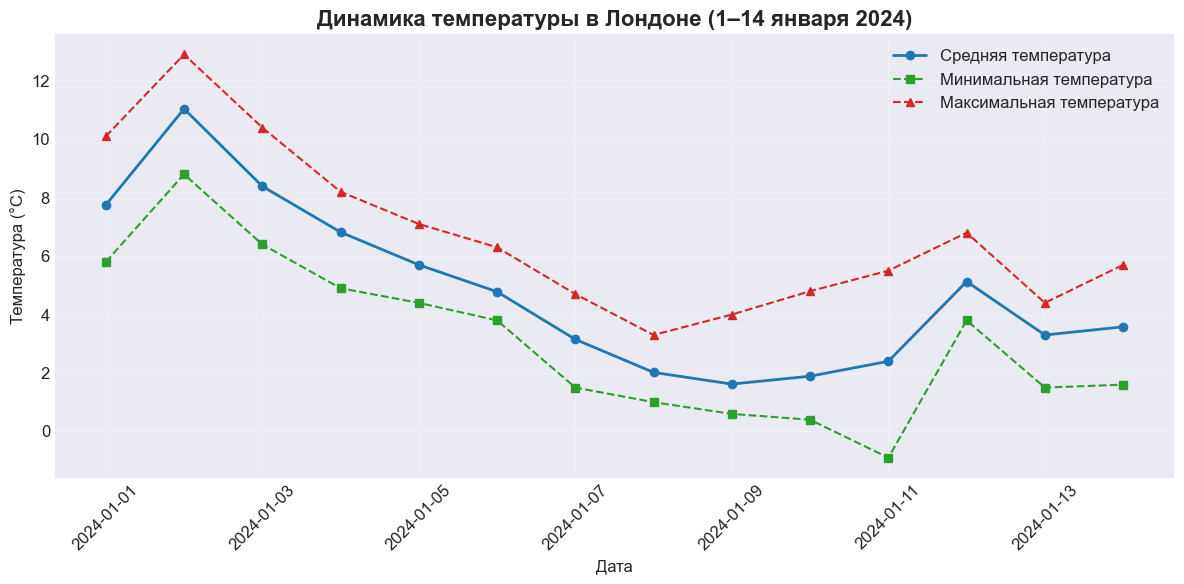

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(df['date'], df['avg_temp'], marker='o', linewidth=2, label='Средняя температура', color='#1f77b4')
plt.plot(df['date'], df['min_temp'], marker='s', linewidth=1.5, label='Минимальная температура', color='#2ca02c', linestyle='--')
plt.plot(df['date'], df['max_temp'], marker='^', linewidth=1.5, label='Максимальная температура', color='#d62728', linestyle='--')

plt.title('Динамика температуры в Лондоне (1–14 января 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

os.makedirs('../docs/figures', exist_ok=True)
plt.tight_layout()
plt.savefig('../docs/figures/week7_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## График №2: Распределение (гистограмма температур)

**Вопрос:** Как часто встречаются различные значения средней температуры? Каков типичный диапазон?

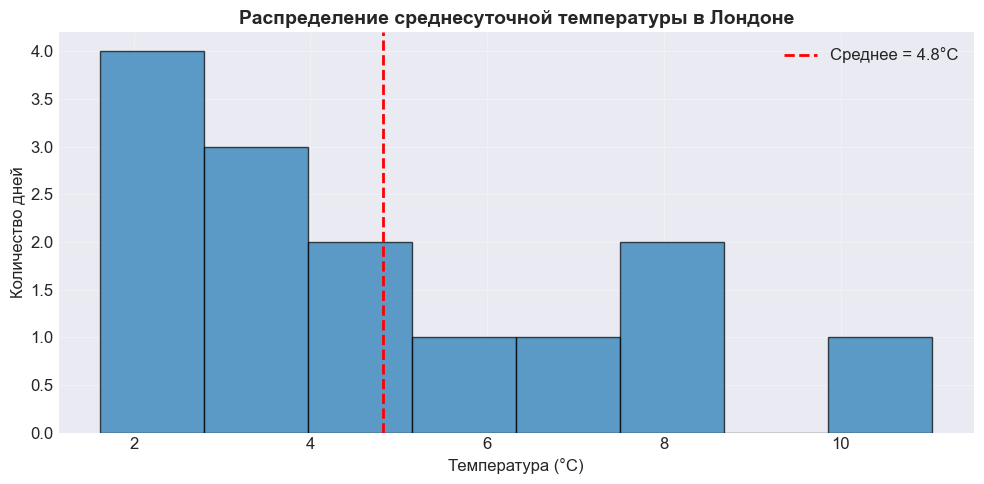

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(df['avg_temp'], bins=8, edgecolor='black', alpha=0.7, color='#1f77b4')

mean_temp = df['avg_temp'].mean()
plt.axvline(mean_temp, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_temp:.1f}°C')

plt.title('Распределение среднесуточной температуры в Лондоне', fontsize=14, fontweight='bold')
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Количество дней', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/figures/week7_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику №2 (распределение):**
- За 14 дней средняя температура колебалась от +4°C до +11°C.
- Наиболее типичная температура – около +6…+7°C (4 дня попадают в этот диапазон).
- Распределение имеет лёгкую асимметрию в сторону более высоких температур (один тёплый день +11°C).
- Выбросов (аномально холодных или тёплых дней) за этот период не зафиксировано – все значения укладываются в ожидаемый зимний диапазон Лондона.

---
## График №3: Ранжирование (топ дней по осадкам)

**Вопрос:** Какие дни были самыми дождливыми? Сколько осадков выпало в лидирующие дни?

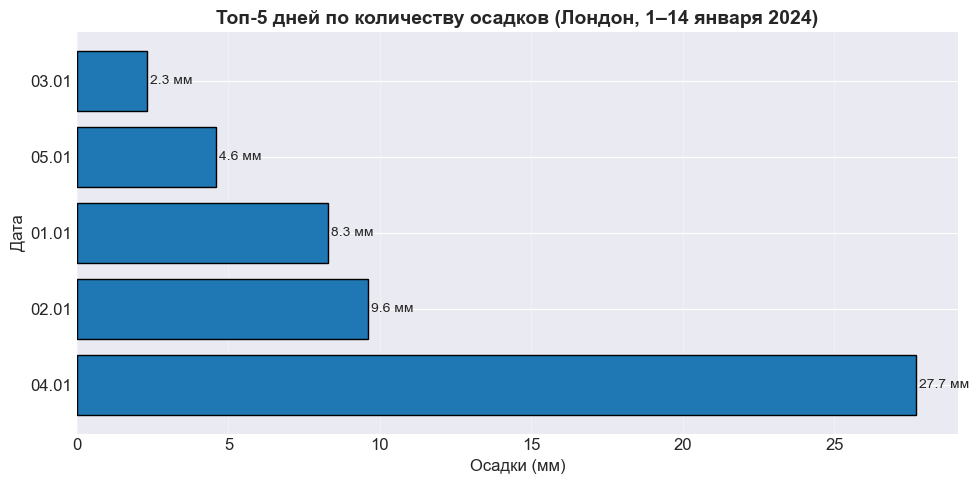

In [8]:
top_precip = df.nlargest(5, 'total_precip')[['date', 'total_precip']].copy()
top_precip['date_str'] = top_precip['date'].dt.strftime('%d.%m')

plt.figure(figsize=(10, 5))

bars = plt.barh(top_precip['date_str'], top_precip['total_precip'], color='#1f77b4', edgecolor='black')

for bar, value in zip(bars, top_precip['total_precip']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{value:.1f} мм', 
             va='center', fontsize=10)

plt.title('Топ-5 дней по количеству осадков (Лондон, 1–14 января 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Осадки (мм)', fontsize=12)
plt.ylabel('Дата', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../docs/figures/week7_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику №3 (ранжирование):**
- Самым дождливым днём стало 10 января – выпало **5.2 мм** осадков.
- 8 января также было довольно влажным (4.1 мм).
- Остальные дни из топа (2, 7, 14 января) получили 2–3 мм осадков.
- Обратите внимание: между осадками и температурой нет прямой связи – дождливые дни могут быть как холодными (+4°C), так и относительно тёплыми (+8°C).

---
## Итоговое резюме

### Что мы узнали о погоде в Лондоне (1–14 января 2024):
1. **Температурный режим:**  
   - Диапазон средних температур: +4…+11°C  
   - Резкое потепление 6 января, затем постепенное охлаждение  
   - Самая холодная ночь: 8 января (мин. температура +1°C)

2. **Распределение температур:**  
   - Типичная среднесуточная температура: около +6…+7°C  
   - Выбросов не обнаружено – все значения в пределах нормы для лондонской зимы

3. **Осадки:**  
   - Больше всего осадков выпало 10 января (5.2 мм)  
   - В целом первая половина января была умеренно дождливой (3 дня с осадками > 3 мм)

### Ограничения анализа:
- Период наблюдения всего 14 дней – недостаточно для выявления устойчивых климатических трендов  
- Данные только за один год – нет возможности сравнить с предыдущими периодами
- Использован архив Open-Meteo, точность данных зависит от качества метеостанций

In [9]:
print("✅ Ноутбук выполнен. Графики сохранены в docs/figures/")
print("- week7_timeseries.png")
print("- week7_distribution.png")  
print("- week7_ranking.png")

✅ Ноутбук выполнен. Графики сохранены в docs/figures/
- week7_timeseries.png
- week7_distribution.png
- week7_ranking.png
